In [1]:
from pathlib import Path
import zipfile
import shutil
import random
import json
import xml.etree.ElementTree as ET

import cv2
import yaml
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from IPython.display import display, Image as IPyImage

In [2]:
PROJECT_ROOT = Path.cwd()

RAW_DIR = PROJECT_ROOT / "raw_data"
UNZIP_DIR = RAW_DIR / "unzipped"

DATASET_DIR = PROJECT_ROOT / "dataset"
IMAGES_DIR = DATASET_DIR / "images"
LABELS_DIR = DATASET_DIR / "labels"

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
CHECK_DIR = OUTPUTS_DIR / "label_checks"
PRED_DIR = OUTPUTS_DIR / "predictions"

for p in [UNZIP_DIR, IMAGES_DIR, LABELS_DIR, OUTPUTS_DIR, CHECK_DIR, PRED_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: /project


In [3]:
zip_files = list(RAW_DIR.glob("*.zip"))
print("Zip files found:", [z.name for z in zip_files])

for zip_path in zip_files:
    out_path = UNZIP_DIR / zip_path.stem
    if out_path.exists():
        print(f"[SKIP] {zip_path.name} already extracted")
        continue

    print(f"[UNZIP] {zip_path.name}")
    out_path.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(out_path)

print("Done.")

Zip files found: ['2022-12-23 Asjo 01_HD 5x stab.zip', '2022-12-02 Asjo 01_stabilized.zip', '2022-12-03 Nyland 01_stabilized.zip', '2022-12-04 Bjenberg 02.zip']
[UNZIP] 2022-12-23 Asjo 01_HD 5x stab.zip
[UNZIP] 2022-12-02 Asjo 01_stabilized.zip
[UNZIP] 2022-12-03 Nyland 01_stabilized.zip
[UNZIP] 2022-12-04 Bjenberg 02.zip
Done.


In [4]:
video_exts = {".mp4", ".avi", ".mov", ".mkv"}
image_exts = {".jpg", ".jpeg", ".png"}
annot_exts = {".xml", ".json", ".txt"}

videos, images, annots = [], [], []

for f in UNZIP_DIR.rglob("*"):
    if f.is_file():
        ext = f.suffix.lower()
        if ext in video_exts:
            videos.append(f)
        elif ext in image_exts:
            images.append(f)
        elif ext in annot_exts:
            annots.append(f)

print("Videos:", len(videos))
print("Images:", len(images))
print("Annotations:", len(annots))

print("\nSample videos:")
for x in videos[:10]:
    print(x)

print("\nSample annotations:")
for x in annots[:10]:
    print(x)

Videos: 4
Images: 0
Annotations: 4

Sample videos:
/project/raw_data/unzipped/2022-12-02 Asjo 01_stabilized/2022-12-02 Asjo 01_stabilized.MP4
/project/raw_data/unzipped/2022-12-03 Nyland 01_stabilized/2022-12-03 Nyland 01_stabilized.mp4
/project/raw_data/unzipped/2022-12-04 Bjenberg 02/2022-12-04 Bjenberg 02.MP4
/project/raw_data/unzipped/2022-12-23 Asjo 01_HD 5x stab/2022-12-23 Asjo 01_HD 5x stab.MP4

Sample annotations:
/project/raw_data/unzipped/2022-12-02 Asjo 01_stabilized/2022-12-02 Asjo 01_stabilized.xml
/project/raw_data/unzipped/2022-12-03 Nyland 01_stabilized/2022-12-03 Nyland 01_stabilized.xml
/project/raw_data/unzipped/2022-12-04 Bjenberg 02/2022-12-04 Bjenberg 02.xml
/project/raw_data/unzipped/2022-12-23 Asjo 01_HD 5x stab/2022-12-23 Asjo 01_HD 5x stab.xml


In [5]:
def decide_split(path_str: str):
    s = path_str.lower()

    if "nyland" in s and "stabilized" in s:
        return "val"

    if "asjo" in s and "hd" in s and "5x" in s:
        return "train"

    if "asjo" in s and "01_stabilized" in s:
        return "train"

    # safest interpretation: Bjenberg/Hjenberg is the test sequence
    if "bjenberg" in s or "hjenberg" in s:
        return "test"

    return None

for split in ["train", "val", "test"]:
    (IMAGES_DIR / split).mkdir(parents=True, exist_ok=True)
    (LABELS_DIR / split).mkdir(parents=True, exist_ok=True)

In [6]:
def parse_cvat_xml(xml_path: Path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    image_mode = root.findall(".//image")
    track_mode = root.findall(".//track")

    return root, image_mode, track_mode


def box_to_yolo(xtl, ytl, xbr, ybr, img_w, img_h):
    xtl = max(0, min(float(xtl), img_w - 1))
    xbr = max(0, min(float(xbr), img_w - 1))
    ytl = max(0, min(float(ytl), img_h - 1))
    ybr = max(0, min(float(ybr), img_h - 1))

    bw = xbr - xtl
    bh = ybr - ytl

    if bw <= 1 or bh <= 1:
        return None

    xc = xtl + bw / 2
    yc = ytl + bh / 2

    return 0, xc / img_w, yc / img_h, bw / img_w, bh / img_h


def save_yolo_label(label_path: Path, boxes, img_w, img_h):
    lines = []
    for (xtl, ytl, xbr, ybr) in boxes:
        out = box_to_yolo(xtl, ytl, xbr, ybr, img_w, img_h)
        if out is None:
            continue
        cls, xc, yc, bw, bh = out
        lines.append(f"{cls} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")

    label_path.write_text("\n".join(lines), encoding="utf-8")


def find_matching_video(xml_path: Path, video_list):
    xml_stem = xml_path.stem.lower()

    for v in video_list:
        if v.parent == xml_path.parent and v.stem.lower() == xml_stem:
            return v

    for v in video_list:
        if v.stem.lower() == xml_stem:
            return v

    for v in video_list:
        if xml_stem in v.stem.lower() or v.stem.lower() in xml_stem:
            return v

    return None

In [7]:
video_files = [p for p in UNZIP_DIR.rglob("*") if p.suffix.lower() in video_exts]
xml_files = list(UNZIP_DIR.rglob("*.xml"))

print("Video files:", len(video_files))
print("XML files:", len(xml_files))

Video files: 4
XML files: 4


In [8]:
def convert_image_xml(xml_path: Path, split: str):
    root, image_mode, track_mode = parse_cvat_xml(xml_path)

    if not image_mode:
        return False

    print(f"[IMAGE XML] {xml_path.name} -> {split}")

    for image_tag in tqdm(image_mode):
        img_name = image_tag.attrib.get("name", "")
        img_w = int(float(image_tag.attrib["width"]))
        img_h = int(float(image_tag.attrib["height"]))

        candidates = list(xml_path.parent.rglob(Path(img_name).name))
        if not candidates:
            continue

        src_img = candidates[0]
        dst_img = IMAGES_DIR / split / src_img.name
        dst_lbl = LABELS_DIR / split / f"{src_img.stem}.txt"

        shutil.copy2(src_img, dst_img)

        boxes = []
        for box in image_tag.findall("box"):
            xtl = box.attrib["xtl"]
            ytl = box.attrib["ytl"]
            xbr = box.attrib["xbr"]
            ybr = box.attrib["ybr"]
            boxes.append((xtl, ytl, xbr, ybr))

        save_yolo_label(dst_lbl, boxes, img_w, img_h)

    return True

In [9]:
def convert_video_xml(xml_path: Path, split: str):
    root, image_mode, track_mode = parse_cvat_xml(xml_path)
    if not track_mode:
        return False

    video_path = find_matching_video(xml_path, video_files)
    if video_path is None:
        print(f"[SKIP] no matching video for {xml_path}")
        return False

    print(f"[VIDEO XML] {xml_path.name} -> {split}")

    boxes_by_frame = {}

    for track in track_mode:
        label = track.attrib.get("label", "").lower()

        for box in track.findall("box"):
            outside = int(box.attrib.get("outside", 0))
            if outside == 1:
                continue

            frame_id = int(box.attrib["frame"])
            xtl = box.attrib["xtl"]
            ytl = box.attrib["ytl"]
            xbr = box.attrib["xbr"]
            ybr = box.attrib["ybr"]

            boxes_by_frame.setdefault(frame_id, []).append((xtl, ytl, xbr, ybr))

    cap = cv2.VideoCapture(str(video_path))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    base = video_path.stem.replace(" ", "_")

    for frame_id in tqdm(sorted(boxes_by_frame.keys())):
        if frame_id < 0 or frame_id >= total_frames:
            continue

        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
        ok, frame = cap.read()
        if not ok:
            continue

        h, w = frame.shape[:2]

        img_name = f"{base}_frame_{frame_id:06d}.jpg"
        lbl_name = f"{base}_frame_{frame_id:06d}.txt"

        img_path = IMAGES_DIR / split / img_name
        lbl_path = LABELS_DIR / split / lbl_name

        cv2.imwrite(str(img_path), frame)
        save_yolo_label(lbl_path, boxes_by_frame[frame_id], w, h)

    cap.release()
    return True

In [10]:
converted = []

for xml_path in xml_files:
    split = decide_split(str(xml_path))
    if split is None:
        print("[SKIP split]", xml_path)
        continue

    done = convert_image_xml(xml_path, split)
    if not done:
        done = convert_video_xml(xml_path, split)

    converted.append((xml_path.name, split, done))

pd.DataFrame(converted, columns=["xml_file", "split", "converted"]).head(20)

[VIDEO XML] 2022-12-02 Asjo 01_stabilized.xml -> train


100%|██████████| 801/801 [03:27<00:00,  3.86it/s]


[VIDEO XML] 2022-12-03 Nyland 01_stabilized.xml -> val


100%|██████████| 1203/1203 [06:17<00:00,  3.18it/s]


[VIDEO XML] 2022-12-04 Bjenberg 02.xml -> test


100%|██████████| 4003/4003 [17:46<00:00,  3.76it/s]


[VIDEO XML] 2022-12-23 Asjo 01_HD 5x stab.xml -> train


100%|██████████| 1252/1252 [03:52<00:00,  5.38it/s]


,xml_file,split,converted
0,2022-12-02 Asjo 01_stabilized.xml,train,True
1,2022-12-03 Nyland 01_stabilized.xml,val,True
2,2022-12-04 Bjenberg 02.xml,test,True
3,2022-12-23 Asjo 01_HD 5x stab.xml,train,True


In [11]:
yaml_data = {
    "path": str(DATASET_DIR.resolve()),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {
        0: "car"
    }
}

yaml_path = DATASET_DIR / "nvd.yaml"
with open(yaml_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(yaml_data, f, sort_keys=False)

print("Saved:", yaml_path)
print(yaml_path.read_text())

Saved: /project/dataset/nvd.yaml
path: /project/dataset
train: images/train
val: images/val
test: images/test
names:
  0: car



In [12]:
summary = []

for split in ["train", "val", "test"]:
    n_img = len(list((IMAGES_DIR / split).glob("*")))
    n_lbl = len(list((LABELS_DIR / split).glob("*.txt")))
    summary.append([split, n_img, n_lbl])

df_summary = pd.DataFrame(summary, columns=["split", "num_images", "num_labels"])
display(df_summary)

,split,num_images,num_labels
0,train,2003,2003
1,val,1203,1203
2,test,4003,4003


In [13]:
def draw_yolo_boxes(img_path: Path, lbl_path: Path, out_path: Path = None):
    img = cv2.imread(str(img_path))
    if img is None:
        return None

    h, w = img.shape[:2]

    if lbl_path.exists():
        lines = lbl_path.read_text().strip().splitlines()
        for line in lines:
            parts = line.strip().split()
            if len(parts) != 5:
                continue

            cls, xc, yc, bw, bh = map(float, parts)
            x1 = int((xc - bw / 2) * w)
            y1 = int((yc - bh / 2) * h)
            x2 = int((xc + bw / 2) * w)
            y2 = int((yc + bh / 2) * h)

            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img, "car", (x1, max(0, y1 - 5)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    if out_path is not None:
        cv2.imwrite(str(out_path), img)

    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

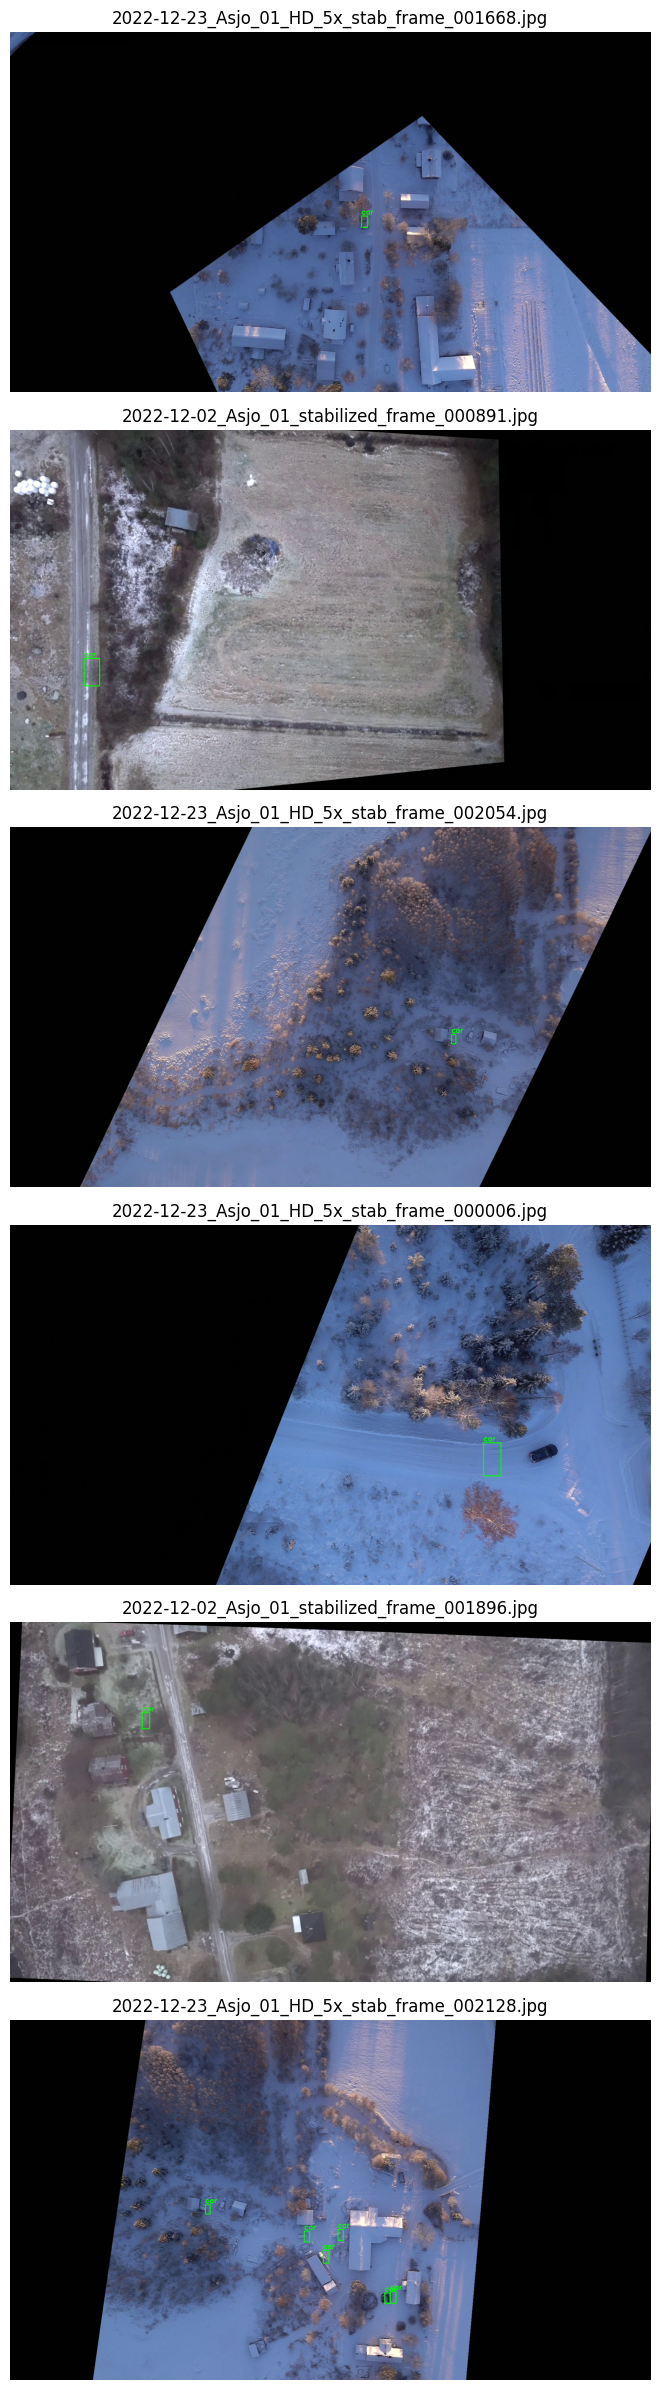

In [14]:
train_imgs = list((IMAGES_DIR / "train").glob("*.jpg"))
sample_imgs = random.sample(train_imgs, min(6, len(train_imgs)))

fig, axes = plt.subplots(len(sample_imgs), 1, figsize=(12, 4 * len(sample_imgs)))
if len(sample_imgs) == 1:
    axes = [axes]

for ax, img_path in zip(axes, sample_imgs):
    lbl_path = LABELS_DIR / "train" / f"{img_path.stem}.txt"
    out_path = CHECK_DIR / img_path.name
    vis = draw_yolo_boxes(img_path, lbl_path, out_path=out_path)
    ax.imshow(vis)
    ax.set_title(img_path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [15]:
from ultralytics import YOLO

In [16]:
baseline_model = YOLO("yolov9c.pt")

baseline_results = baseline_model.train(
    data=str(yaml_path),
    epochs=50,
    imgsz=640,
    batch=4,
    project="outputs",
    name="yolov9_baseline",
    pretrained=True,
    patience=15,
    workers=2,
    device='0',
    plots=True,
    save=True
)

Ultralytics 8.4.47 🚀 Python-3.11.15 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 10822MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/project/dataset/nvd.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9c.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov9_baseline, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

In [17]:
aug_model = YOLO("yolov9c.pt")

aug_results = aug_model.train(
    data=str(yaml_path),
    epochs=80,
    imgsz=960,
    batch=2,
    project="outputs",
    name="yolov9_augmented",
    pretrained=True,
    patience=20,
    workers=2,
    device=0,   # change to "cpu" if needed
    plots=True,
    save=True,

    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=30.0,
    translate=0.1,
    scale=0.5,
    perspective=0.0005,
    fliplr=0.5,
    flipud=0.0,
    mosaic=1.0,
    mixup=0.1,
    erasing=0.2
)

Ultralytics 8.4.47 🚀 Python-3.11.15 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 10822MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/project/dataset/nvd.yaml, degrees=30.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.2, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov9c.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov9_augmented, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_ma

In [21]:
best_model_path = PROJECT_ROOT / "runs" / "detect" / "outputs" / "yolov9_augmented" / "weights" / "best.pt"
print(best_model_path)
print(best_model_path.exists())

/project/runs/detect/outputs/yolov9_augmented/weights/best.pt
True


In [23]:
from ultralytics import YOLO

best_model = YOLO(str(best_model_path))

test_metrics = best_model.val(
    data=str(yaml_path),
    split="test",
    imgsz=960,
    batch=2,
    device=0,   # change to "cpu" if needed
    project="outputs",
    name="test_eval",
    plots=True,
    save_json=True
)

summary_metrics = {
    "precision": float(test_metrics.box.mp),
    "recall": float(test_metrics.box.mr),
    "mAP50": float(test_metrics.box.map50),
    "mAP50_95": float(test_metrics.box.map),
}

summary_metrics

Ultralytics 8.4.47 🚀 Python-3.11.15 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 10822MiB)
YOLOv9c summary (fused): 156 layers, 25,320,019 parameters, 0 gradients, 102.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4122.0±1413.9 MB/s, size: 758.7 KB)
val: Scanning /project/dataset/labels/test... 4003 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4003/4003 1.1Kit/s 3.8s0.1ss
val: New cache created: /project/dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2002/2002 22.3it/s 1:30<0.1ss
                   all       4003      14985    0.00463     0.0696   0.000948    0.00014
Speed: 0.9ms preprocess, 17.0ms inference, 0.0ms loss, 0.8ms postprocess per image
Saving /project/runs/detect/outputs/test_eval/predictions.json...
Results saved to /project/runs/detect/outputs/test_eval


{'precision': 0.004631191943590927,
 'recall': 0.06960293626960294,
 'mAP50': 0.0009479900753116267,
 'mAP50_95': 0.00013988396768834177}

In [24]:
metrics_path = OUTPUTS_DIR / "test_metrics.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(summary_metrics, f, indent=4)

print("Saved:", metrics_path)
print(metrics_path.read_text())

Saved: /project/outputs/test_metrics.json
{
    "precision": 0.004631191943590927,
    "recall": 0.06960293626960294,
    "mAP50": 0.0009479900753116267,
    "mAP50_95": 0.00013988396768834177
}


In [25]:
test_images = list((IMAGES_DIR / "test").glob("*.jpg"))
sample_test_images = random.sample(test_images, min(20, len(test_images)))

sample_input_dir = OUTPUTS_DIR / "sample_test_input"
sample_input_dir.mkdir(parents=True, exist_ok=True)

for img in sample_test_images:
    shutil.copy2(img, sample_input_dir / img.name)

pred_model = YOLO(str(best_model_path))
pred_model.predict(
    source=str(sample_input_dir),
    imgsz=960,
    conf=0.25,
    iou=0.5,
    save=True,
    project="outputs",
    name="sample_predictions"
)


image 1/20 /project/outputs/sample_test_input/2022-12-04_Bjenberg_02_frame_000164.jpg: 544x960 (no detections), 76.5ms
image 2/20 /project/outputs/sample_test_input/2022-12-04_Bjenberg_02_frame_000187.jpg: 544x960 (no detections), 19.2ms
image 3/20 /project/outputs/sample_test_input/2022-12-04_Bjenberg_02_frame_000231.jpg: 544x960 (no detections), 19.2ms
image 4/20 /project/outputs/sample_test_input/2022-12-04_Bjenberg_02_frame_000734.jpg: 544x960 (no detections), 19.1ms
image 5/20 /project/outputs/sample_test_input/2022-12-04_Bjenberg_02_frame_000881.jpg: 544x960 (no detections), 19.1ms
image 6/20 /project/outputs/sample_test_input/2022-12-04_Bjenberg_02_frame_001122.jpg: 544x960 (no detections), 19.1ms
image 7/20 /project/outputs/sample_test_input/2022-12-04_Bjenberg_02_frame_001262.jpg: 544x960 (no detections), 19.1ms
image 8/20 /project/outputs/sample_test_input/2022-12-04_Bjenberg_02_frame_001760.jpg: 544x960 (no detections), 19.1ms
image 9/20 /project/outputs/sample_test_input/2

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'car'}
 obb: None
 orig_img: array([[[ 27,  24,  26],
         [ 20,  17,  19],
         [ 17,  14,  16],
         ...,
         [125, 107, 108],
         [122, 104, 105],
         [117,  99,  98]],
 
        [[ 30,  27,  29],
         [ 21,  18,  20],
         [ 16,  13,  15],
         ...,
         [121, 103, 104],
         [124, 106, 107],
         [119, 101, 100]],
 
        [[ 36,  33,  35],
         [ 26,  23,  25],
         [ 18,  16,  16],
         ...,
         [123, 105, 106],
         [124, 106, 107],
         [113,  95,  94]],
 
        ...,
 
        [[ 68,  54,  58],
         [ 71,  57,  61],
         [ 71,  57,  61],
         ...,
         [ 53,  42,  44],
         [ 47,  36,  38],
         [ 51,  40,  42]],
 
        [[ 62,  47,  51],
         [ 66,  51,  55],
         [ 66,  52,  56],
         ...,
         [ 55,  44,  

In [26]:
def eval_model(model_path, imgsz=960):
    model = YOLO(str(model_path))
    m = model.val(
        data=str(yaml_path),
        split="test",
        imgsz=imgsz,
        batch=2,
        device=0,
        plots=False
    )
    return {
        "Precision": float(m.box.mp),
        "Recall": float(m.box.mr),
        "mAP50": float(m.box.map50),
        "mAP50-95": float(m.box.map),
    }

baseline_path = PROJECT_ROOT / "outputs" / "yolov9_baseline" / "weights" / "best.pt"
aug_path = PROJECT_ROOT / "outputs" / "yolov9_augmented" / "weights" / "best.pt"

rows = []
if baseline_path.exists():
    rows.append({"Model": "YOLOv9 baseline", **eval_model(baseline_path, imgsz=640)})
if aug_path.exists():
    rows.append({"Model": "YOLOv9 augmented", **eval_model(aug_path, imgsz=960)})

compare_df = pd.DataFrame(rows)
display(compare_df)

compare_df.to_csv(OUTPUTS_DIR / "model_comparison.csv", index=False)

""
